In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr

In [2]:
import sys

In [3]:
sys.path.append("/nfs/home/aoku/software/miniconda3/lib/python3.11/site-packages")

In [4]:
# Load bulk data
cell_lines_bulk = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/GSE220608/GSE220605_DataMatrix_Mixture_CellLines_Bulk_RNA-seq.csv.gz", index_col=0)

In [5]:
cell_lines_bulk = cell_lines_bulk.T

In [6]:
cell_lines_bulk.iloc[:,0:4].head(38)

,A1BG,A1BG-AS1,A1CF,A2M
BT474_1,0,3,0,0
BT474_2,0,2,2,0
BT474_3,3,10,0,0
T47D_1,126,200,1,0
T47D_2,155,160,0,0
T47D_3,139,185,1,0
MCF7_1,55,134,0,11
MCF7_2,46,187,0,19
MCF7_3,65,188,0,12
Thp1_1,68,72,0,4


In [7]:
# Load ground truth 
cell_prop = pd.read_excel("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/GSE220608/ground_truth.xlsx")

In [8]:
cell_prop.head(38)

,Cell type,Mixture,Tissue,Cell count,Flow count,Single-cell RNA count
0,Jurkat,M1,Blood,0.100,0.198773,0.173927
1,THP1,M1,Blood,0.050,0.042367,0.077073
2,BT474,M1,Breast,0.165,0.115856,0.144309
3,MCF7,M1,Breast,0.020,0.025897,0.015458
4,T47D,M1,Breast,0.660,0.614153,0.586855
5,hMSC,M1,Stem cell,0.005,0.002953,0.002378
6,Jurkat,M2,Blood,0.050,0.076134,0.081579
7,THP1,M2,Blood,0.100,0.095533,0.163053
8,BT474,M2,Breast,0.625,0.574893,0.549579
9,MCF7,M2,Breast,0.135,0.174487,0.127368


In [9]:
# Read single cell data (reference)
path = "/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/GSE220608/GSM6807287_cleanso.h5ad"

# Read the h5ad file
adata = sc.read_h5ad(path)

In [10]:
adata

AnnData object with n_obs × n_vars = 42590 × 36581
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Percent_mito', 'qc', 'RNA_snn_res.0.1', 'seurat_clusters', 'type'
    var: 'gene_name'

In [11]:
adata.obs["orig.ident"].unique()

['GSM6807287_M1', 'GSM6807288_M2', 'GSM6807289_M3', 'GSM6807290_M4', 'GSM6807291_M5', 'GSM6807292_M6']
Categories (6, object): ['GSM6807287_M1', 'GSM6807288_M2', 'GSM6807289_M3', 'GSM6807290_M4', 'GSM6807291_M5', 'GSM6807292_M6']

In [12]:
# Prep data for scVI
#Get ensembl IDs - map gene symbol to ensembl ID
gene_ids = pd.read_csv("/gpfs/commons/groups/compbio/projects/CZI_endom/RNA_temp/gene_names_gene_ids_czi_endo.csv", index_col= False)

gene_id_dict = pd.DataFrame({
    'gene_symbol': gene_ids["gene_name"],
    'ensembl_id': gene_ids["gene_id"]})

gene_id_dict = gene_id_dict.set_index('gene_symbol')['ensembl_id'].to_dict()

ensembl_ids = [gene_id_dict.get(gene, 'NA') for gene in adata.var["gene_name"]]

# Add ensembl IDs to anndata object
adata.var["ensembl_id"] = ensembl_ids
adata.var_names = ensembl_ids

# Remove duplicated IDs
adata = adata[:, ~adata.var["ensembl_id"].duplicated()].copy()

# Check for duplicated IDs
adata.var["ensembl_id"].duplicated().any()

False

In [13]:
adata.obs["cell_index"]  = adata.obs.index #required for geneformer
adata.obs["cell_id"] = adata.obs["cell_index"] #required for geneformer

In [14]:
adata.obs['n_counts'] = np.array(adata.X.sum(axis=1)).flatten() #number of transcripts per cell

In [15]:
adata.obs["type"].value_counts()

type
T47D      12836
BT474     11528
MCF7       6562
Jurkat     5729
Thp1       5714
hMSC        221
Name: count, dtype: int64

In [16]:
#adata.write_h5ad("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/GSE220608/geneformer/GSM6807287_cleanso_for_geneformer.h5ad")

#### Visualize geneformer embeddings 

In [19]:
gf_embeddings = pd.read_csv("/gpfs/commons/groups/compbio/projects/rf_projects/deconv_data/GSE220608/geneformer/output/cell_line_gf_embed.csv", index_col=0)

In [20]:
gf_embeddings.head()

,0,1,2,3,4,5,6,7,8,9,...,1145,1146,1147,1148,1149,1150,1151,type,cell_id,cell_index
0,0.071295,0.070180,0.063590,0.020090,-0.380899,-0.028128,0.097966,0.132389,0.017176,0.224527,...,-0.180396,0.201332,0.658561,-0.180762,-0.203038,0.052371,-0.042354,T47D,AAACCCAAGACCAGCA-1_1,AAACCCAAGACCAGCA-1_1
1,0.086999,0.052682,0.022082,0.005225,-0.350331,-0.020342,0.065627,0.133220,0.011442,0.235830,...,-0.169173,0.147492,0.663319,-0.170596,-0.168212,0.046993,-0.010694,BT474,AAACCCACAGCTATAC-1_1,AAACCCACAGCTATAC-1_1
2,0.089513,0.060388,0.113715,0.029168,-0.324860,-0.009679,0.081519,0.186956,0.031649,0.187671,...,-0.162890,0.180658,0.655007,-0.165468,-0.254728,0.120804,-0.009261,T47D,AAACCCAGTTCTAACG-1_1,AAACCCAGTTCTAACG-1_1
3,0.099913,0.084976,0.069792,0.043376,-0.351579,-0.017135,0.070878,0.148472,0.048602,0.196667,...,-0.163435,0.174805,0.684352,-0.185883,-0.199278,0.068821,-0.020346,T47D,AAACCCAGTTGCCATA-1_1,AAACCCAGTTGCCATA-1_1
4,0.082500,0.058838,0.096379,0.033347,-0.363253,-0.015588,0.098363,0.120947,0.036411,0.233456,...,-0.113810,0.164772,0.672506,-0.209763,-0.209487,0.112646,0.003897,T47D,AAACGAAAGATGGCAC-1_1,AAACGAAAGATGGCAC-1_1


In [33]:
gf_embeddings.index = gf_embeddings.cell_index
gf_embeddings = gf_embeddings.loc[adata.obs.index, :]

In [35]:
pd.Series(adata.obs.index == gf_embeddings.cell_index).value_counts()

True    42590
Name: count, dtype: int64

In [40]:
adata

AnnData object with n_obs × n_vars = 42590 × 36581
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'Percent_mito', 'qc', 'RNA_snn_res.0.1', 'seurat_clusters', 'type', 'cell_index', 'cell_id', 'n_counts'
    var: 'gene_name', 'ensembl_id'

In [41]:
# Add geneformer embeddings
adata.obsm["geneformer"] = np.array(gf_embeddings.iloc[:, 0:1152])

In [49]:
# Normalize, compute neighbors, and run UMAP
sc.pp.neighbors(adata, use_rep="geneformer",  n_neighbors=10)
sc.tl.umap(adata)

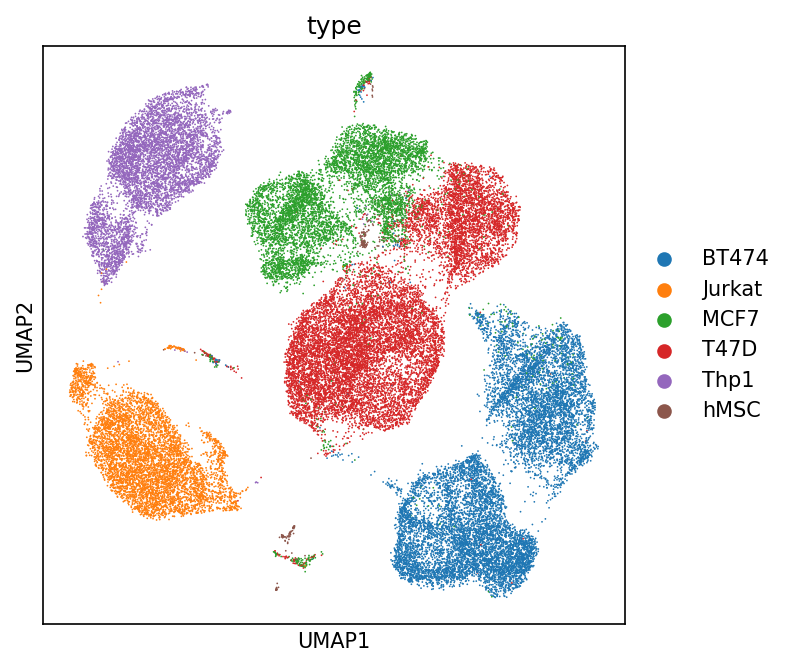

In [50]:
# Now plot
with plt.rc_context({"figure.figsize": (5, 5), "figure.dpi": (150)}):
    sc.pl.umap(adata, color="orig.ident")